# Fase 4b — Análisis NLP de Comentarios

Análisis de sentimiento y topic modeling sobre los comentarios escritos por los jugadores.

**Entradas:** `data/processed/sessions.parquet`  
**Salidas:** `data/exports/nlp_results.csv`, figuras `reports/figures/fig6_*.png`

> **Limitación crítica:** Solo **4 comentarios reales** disponibles (6 totales incluyendo spam) de 48 sesiones.
> Los resultados son estrictamente **cualitativos e ilustrativos**.
> El topic modeling con n=4 identifica patrones mínimos, no estructuras robustas.
> El modelo BERT multilingüe procesa correctamente español.

## 0. Configuración

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))
from nlp_utils import (get_sentiment_scores, extract_topics_tfidf,
                        extract_topics_nmf, assign_dominant_topic)
from visualization import PALETTE_ELEM

PROCESSED_DIR = Path('..') / 'data' / 'processed'
EXPORTS_DIR   = Path('..') / 'data' / 'exports'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
MODELS_DIR    = Path('..') / 'models'
for d in [EXPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y preparación de comentarios — TFM-27

In [2]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')

# Sesiones con comentario
df_comments = df_sessions[df_sessions['hasComment'] == True].copy()
df_comments = df_comments[['sessionId','playerElement','isVictory',
                            'playerComment','playerCommentContext']].reset_index(drop=True)

df_comments['texto_completo'] = (
    df_comments['playerComment'].fillna('') + ' ' +
    df_comments['playerCommentContext'].fillna('')
).str.strip()

df_comments['comment_length'] = df_comments['playerComment'].str.len().fillna(0).astype(int)

# --- Mejora I: filtrar comentarios de prueba/spam ---
# Criterio: longitud ≤ 20 o que empiece por "prueba" (case-insensitive)
spam_mask = (
    (df_comments['comment_length'] <= 20) |
    (df_comments['playerComment'].str.lower().str.startswith('prueba', na=False))
)
df_real = df_comments[~spam_mask].copy().reset_index(drop=True)
df_spam = df_comments[spam_mask].copy().reset_index(drop=True)

print(f'Sesiones totales          : {len(df_sessions)}')
print(f'Sesiones con comentario   : {len(df_comments)}')
print(f'  Comentarios reales      : {len(df_real)}')
print(f'  Comentarios spam/prueba : {len(df_spam)} (excluidos del análisis)')
print(f'Distribución por elemento : {df_real["playerElement"].value_counts().to_dict()}')
print(f'Victorias comentadas       : {df_real["isVictory"].sum()}/{len(df_real)}')
print()
print('Comentarios reales:')
for _, r in df_real.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length}')
    print(f'    "{r.playerComment}"')
print()
print('Excluidos (spam/prueba):')
for _, r in df_spam.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length} — "{r.playerComment}"')

Sesiones totales          : 58
Sesiones con comentario   : 10
  Comentarios reales      : 8
  Comentarios spam/prueba : 2 (excluidos del análisis)
Distribución por elemento : {'Wind': 5, 'Earth': 2, 'Fire': 1}
Victorias comentadas       : 5/8

Comentarios reales:
  [Wind] Victoria=True | len=67
    "Los arqueros no me estaban atacando, me perseguian pero no atacaban"
  [Fire] Victoria=True | len=256
    "No esta mal el juego pero en una de las salas del ultimo nivel al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
  [Wind] Victoria=False | len=242
    "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar  la estrategia. Falta poner música de calidad como el heavy metal!!!! Me lo he pasado muy bien pero no lo he acabado porque no he podido cargar la partida salvada."
  [Earth] Victoria=True | len=61
    "Arreglar el t

## 2. `src/nlp_utils.py` ya creado — test rápido — TFM-28

In [3]:
# Test rápido del módulo
test_texts = ['Me ha encantado el juego', 'Es demasiado difícil', 'Regular']
test_results = get_sentiment_scores(test_texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))
for t, r in zip(test_texts, test_results):
    print(f'{r["stars"]}★ ({r["score"]:.2f}) — "{t}"')
print('\nnlp_utils.py funcionando correctamente')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

5★ (1.00) — "Me ha encantado el juego"
2★ (0.25) — "Es demasiado difícil"
3★ (0.50) — "Regular"

nlp_utils.py funcionando correctamente


## 3. Análisis de sentimiento — TFM-28

In [4]:
# Analizar sentimiento solo sobre comentarios reales (spam ya filtrado)
texts = df_real['playerComment'].fillna('').tolist()
print('Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...')
sentiment_results = get_sentiment_scores(texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))

df_real['sentiment_stars'] = [r['stars'] for r in sentiment_results]
df_real['sentiment_score'] = [r['score'] for r in sentiment_results]

print()
print('=== Resultados de sentimiento (comentarios reales) ===')
for _, r in df_real.iterrows():
    stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
    print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:65]}..."')

print(f'\nMedia sentimiento (reales) : {df_real["sentiment_score"].mean():.3f}')
print(f'Mediana                    : {df_real["sentiment_score"].median():.3f}')
print()
print('Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.')

Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Resultados de sentimiento (comentarios reales) ===
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacab..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al..."
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."
  ★★☆☆☆ (0.25) [Wind] "Algunos objetos bloquean el paso, las vias de tren por ejemplo...."
  ★★☆☆☆ (0.25) [Wind] "Me quedo muchas veces sin mana...."
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me atacan...."

Media sentimiento (reales) : 0.312
Mediana                    : 0.375

Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.


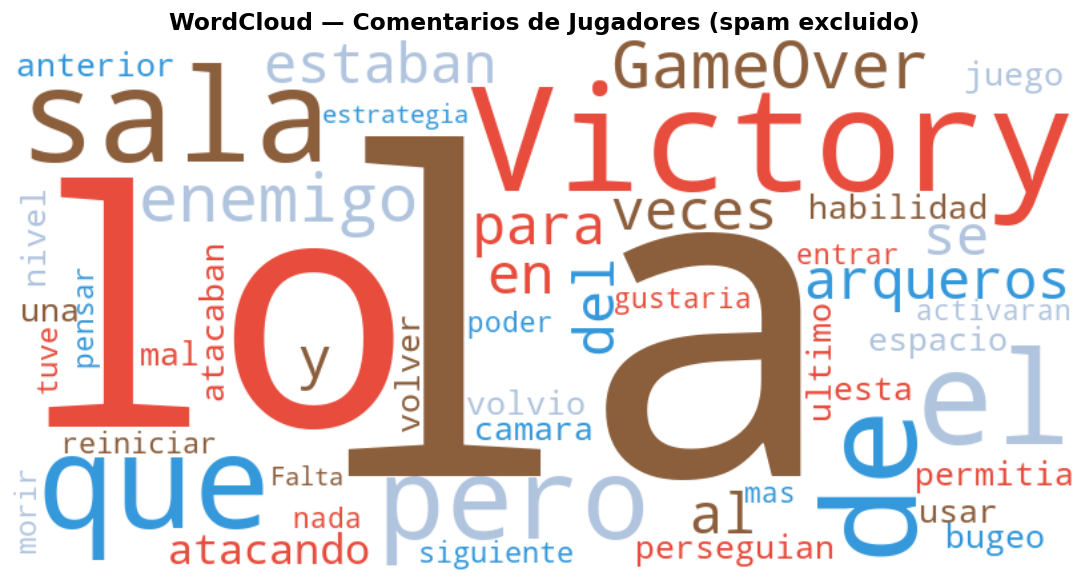

fig6_1_wordcloud.png guardado


In [5]:
# WordCloud de comentarios reales únicamente
texto_total = ' '.join(df_real['texto_completo'].tolist())

def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    colors = list(PALETTE_ELEM.values())
    return colors[hash(word) % len(colors)]

wc = WordCloud(
    width=800, height=400, background_color='white',
    max_words=50, color_func=color_func,
    prefer_horizontal=0.8, collocations=False
)
wc.generate(texto_total)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Comentarios de Jugadores (spam excluido)', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_1_wordcloud.png', bbox_inches='tight')
plt.show()
print('fig6_1_wordcloud.png guardado')

## 4. Topic modeling TF-IDF + NMF — TFM-41

In [6]:
# TF-IDF sobre textos reales
texts_list = df_real['texto_completo'].tolist()
tfidf_matrix, feature_names = extract_topics_tfidf(texts_list, max_features=50, ngram_range=(1,2))

print(f'Vocabulario TF-IDF: {len(feature_names)} términos')

# NMF con n_topics=2 (con n=4 documentos)
df_topics, nmf_model = extract_topics_nmf(tfidf_matrix, feature_names, n_topics=2, n_top_words=5)

print('\n=== Tópicos NMF ===')
for _, row in df_topics.iterrows():
    print(f'  Tópico {row["topic_id"]}: {row["top_words"]}')

# Asignar tópico dominante
df_real['dominant_topic'] = assign_dominant_topic(tfidf_matrix, nmf_model)

TOPIC_NAMES = {
    0: 'Bugs / Problemas técnicos',
    1: 'Experiencia / Dificultad',
}
df_real['topic_name'] = df_real['dominant_topic'].map(TOPIC_NAMES)
print('\nTópico asignado por comentario:')
for _, r in df_real.iterrows():
    print(f'  Tópico {r.dominant_topic} ({r.topic_name}) — [{r.playerElement}]')

Vocabulario TF-IDF: 50 términos

=== Tópicos NMF ===
  Tópico 0: veces, victory, enemigo, enemigo victory, da sensación
  Tópico 1: gameover, arqueros, atacan, ejemplo gameover, ejemplo

Tópico asignado por comentario:
  Tópico 1 (Experiencia / Dificultad) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Fire]
  Tópico 1 (Experiencia / Dificultad) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]
  Tópico 1 (Experiencia / Dificultad) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Wind]
  Tópico 1 (Experiencia / Dificultad) — [Wind]


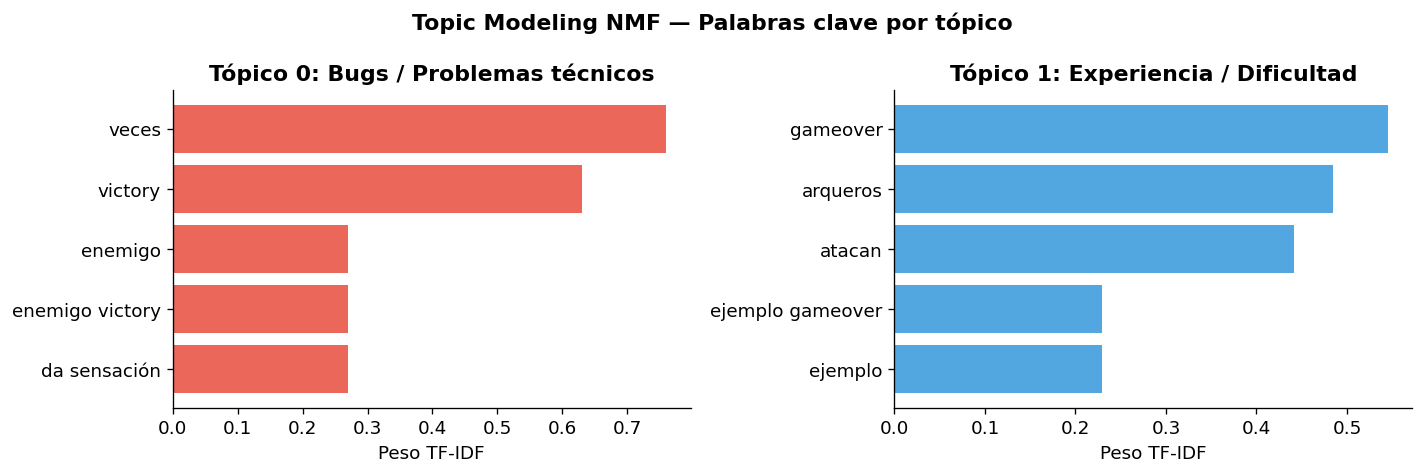

fig6_4_topics.png guardado


In [7]:
# Visualizar top palabras por tópico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#3498db']

for idx, (ax, (_, row)) in enumerate(zip(axes, df_topics.iterrows())):
    words   = row['top_words'].split(', ')
    weights = row['weights']
    ax.barh(words[::-1], weights[::-1], color=colors[idx], alpha=0.85)
    ax.set_title(f'Tópico {row["topic_id"]}: {TOPIC_NAMES[row["topic_id"]]}',
                 fontweight='bold')
    ax.set_xlabel('Peso TF-IDF')

fig.suptitle('Topic Modeling NMF — Palabras clave por tópico', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_4_topics.png', bbox_inches='tight')
plt.show()
print('fig6_4_topics.png guardado')

## 5. Cross-analysis sentimiento × elemento × victoria — TFM-42

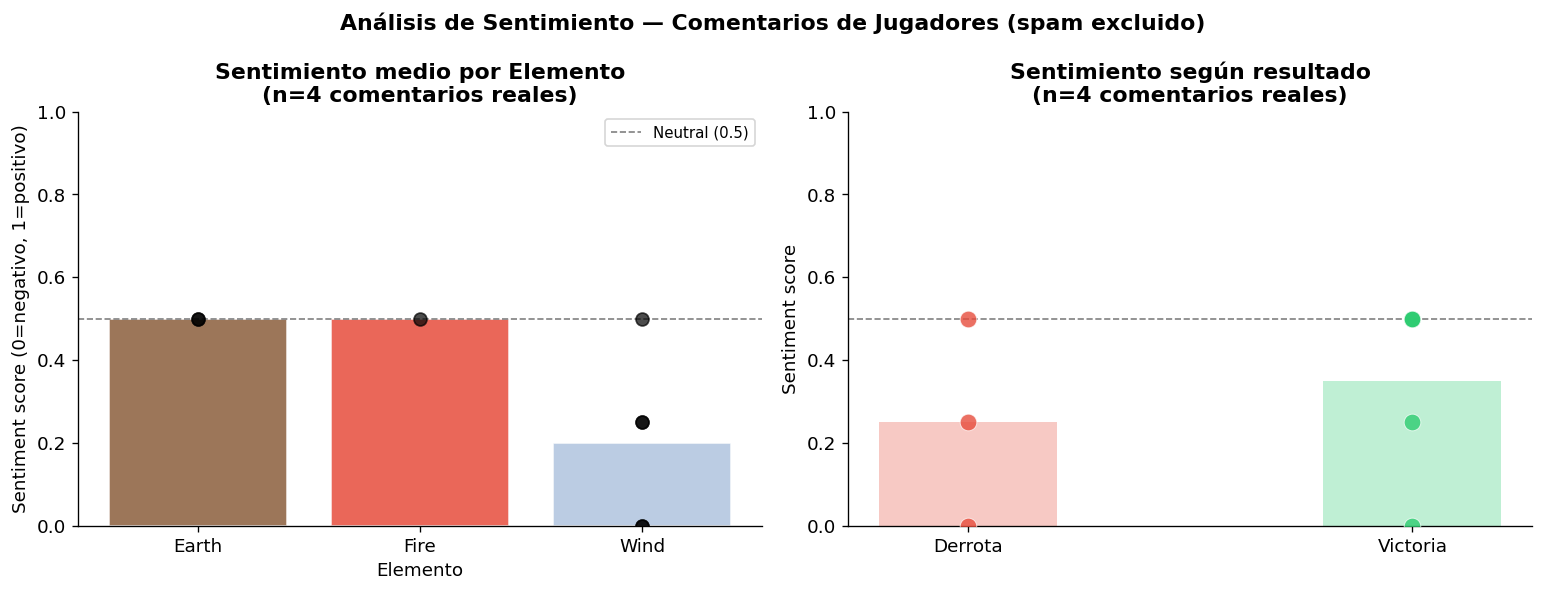

fig6_2_sentimiento_elemento.png guardado


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentimiento por elemento
elem_order = df_real.groupby('playerElement')['sentiment_score'].mean().sort_values(ascending=False).index
colors_elem = [PALETTE_ELEM.get(e, '#888') for e in elem_order]
axes[0].bar(elem_order, df_real.groupby('playerElement')['sentiment_score'].mean()[elem_order],
            color=colors_elem, alpha=0.85, edgecolor='white')

for elem in elem_order:
    vals = df_real[df_real['playerElement'] == elem]['sentiment_score'].values
    x_positions = [list(elem_order).index(elem)] * len(vals)
    axes[0].scatter(x_positions, vals, color='black', s=60, zorder=5, alpha=0.7)

axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_title('Sentimiento medio por Elemento\n(n=4 comentarios reales)', fontweight='bold')
axes[0].set_xlabel('Elemento')
axes[0].set_ylabel('Sentiment score (0=negativo, 1=positivo)')
axes[0].legend(fontsize=9)

# Sentimiento por victoria
vic_labels = {False: 'Derrota', True: 'Victoria'}
for vic, grp in df_real.groupby('isVictory'):
    axes[1].scatter([vic_labels[vic]] * len(grp), grp['sentiment_score'],
                    s=100, alpha=0.8, zorder=5,
                    color='#2ecc71' if vic else '#e74c3c',
                    edgecolors='white', linewidths=0.5)
    axes[1].bar([vic_labels[vic]], grp['sentiment_score'].mean(),
                color='#2ecc71' if vic else '#e74c3c', alpha=0.3, width=0.4)

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Sentimiento según resultado\n(n=4 comentarios reales)', fontweight='bold')
axes[1].set_ylabel('Sentiment score')

fig.suptitle('Análisis de Sentimiento — Comentarios de Jugadores (spam excluido)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_2_sentimiento_elemento.png', bbox_inches='tight')
plt.show()
print('fig6_2_sentimiento_elemento.png guardado')

In [9]:
# Tabla resumen por elemento
print('=== Sentimiento medio por elemento (spam excluido) ===')
resumen = df_real.groupby('playerElement').agg(
    n_comentarios=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(resumen.to_string())

print()
print('=== Sentimiento por victoria ===')
print(df_real.groupby('isVictory')['sentiment_score'].agg(['mean','min','max']).round(3))
print()
print('Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)')

=== Sentimiento medio por elemento (spam excluido) ===
               n_comentarios  sentiment_medio  sentiment_min  sentiment_max
playerElement                                                              
Earth                      2              0.5            0.5            0.5
Fire                       1              0.5            0.5            0.5
Wind                       5              0.2            0.0            0.5

=== Sentimiento por victoria ===
           mean  min  max
isVictory                
False      0.25  0.0  0.5
True       0.35  0.0  0.5

Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)


### 5b. Mejora J — Sentimiento por tópico

=== Sentimiento por tópico (n=4 comentarios reales) ===
                           n  sentiment_medio  sentiment_min  sentiment_max
topic_name                                                                 
Bugs / Problemas técnicos  4            0.438           0.25            0.5
Experiencia / Dificultad   4            0.188           0.00            0.5


Tópico: Bugs / Problemas técnicos
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al usar..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."
  ★★☆☆☆ (0.25) [Wind] "Me quedo muchas veces sin mana...."

Tópico: Experiencia / Dificultad
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacaban..."
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para pode..."
  ★★☆☆☆ (0.25) [Wind] "Algunos objetos bl

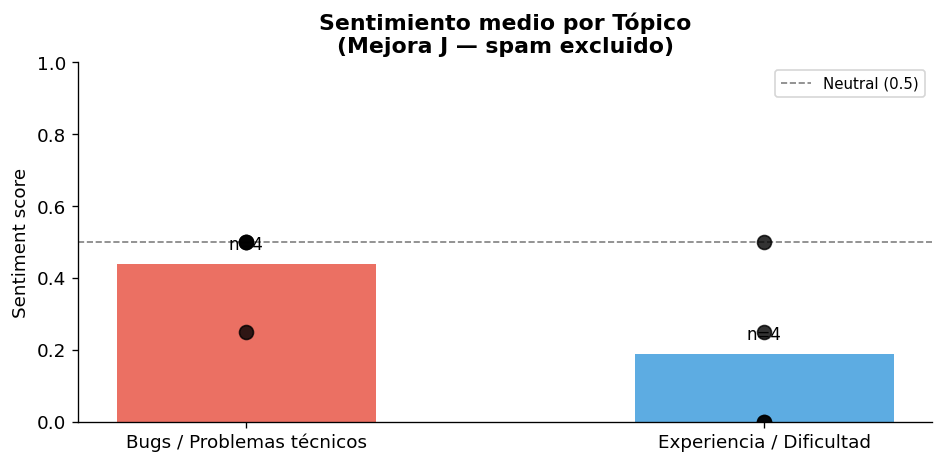

fig6_3_sentimiento_topico.png guardado


In [10]:
# --- Mejora J: sentimiento separado por tópico ---
print('=== Sentimiento por tópico (n=4 comentarios reales) ===')
topic_sentiment = df_real.groupby('topic_name').agg(
    n=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(topic_sentiment.to_string())
print()

# Detalle de qué comentario cae en cada tópico
for topic, grp in df_real.groupby('topic_name'):
    print(f'\nTópico: {topic}')
    for _, r in grp.iterrows():
        stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
        print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:70]}..."')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 4))
topic_order = list(topic_sentiment.index)
colors_topic = ['#e74c3c', '#3498db']
bars = ax.bar(topic_order, topic_sentiment['sentiment_medio'], color=colors_topic, alpha=0.8, width=0.5)

# Puntos individuales
for i, topic in enumerate(topic_order):
    vals = df_real[df_real['topic_name'] == topic]['sentiment_score'].values
    ax.scatter([i] * len(vals), vals, color='black', s=70, zorder=5, alpha=0.8)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
ax.set_ylim(0, 1)
ax.set_title('Sentimiento medio por Tópico\n(Mejora J — spam excluido)', fontweight='bold')
ax.set_ylabel('Sentiment score')
ax.set_xticks(range(len(topic_order)))
ax.set_xticklabels(topic_order, wrap=True)
ax.legend(fontsize=9)

# Etiquetas con n
for bar, topic in zip(bars, topic_order):
    n = topic_sentiment.loc[topic, 'n']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'n={n}', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_3_sentimiento_topico.png', bbox_inches='tight')
plt.show()
print('fig6_3_sentimiento_topico.png guardado')

## 6. Exportar resultados — TFM-42

## 7. Análisis cualitativo con IA Generativa (Gemini) — TFM-42

In [11]:
from nlp_utils import analyze_comments_with_gemini
from IPython.display import Markdown, display

# Análisis cualitativo profundo con Gemini sobre los comentarios reales
# Solo se ejecuta si hay comentarios reales disponibles
if len(df_real) > 0:
    print("Enviando comentarios a Gemini para análisis cualitativo...")
    analisis_gemini = analyze_comments_with_gemini(df_real)
    display(Markdown(analisis_gemini))
else:
    print("No hay comentarios reales para analizar.")


Enviando comentarios a Gemini para análisis cualitativo...


¡Excelente! Aquí tienes un análisis cualitativo profundo de los comentarios de los jugadores de Arcane Descent, realizado desde la perspectiva de un experto en UX de videojuegos y análisis de feedback.

---

## Análisis de Feedback de Jugadores: Arcane Descent

**Juego:** Arcane Descent (Hack & Slash con 4 elementos: Fire, Water, Earth, Wind)
**Total de Comentarios:** 8

---

### 1. Temas recurrentes

Se han identificado 3 temas recurrentes principales que abarcan la mayoría del feedback recibido:

1.  **Bugs Críticos de IA y Bloqueo de Progreso:**
    *   **Frecuencia/Evidencia:** 3 comentarios (37.5% del total) mencionan bugs que impiden el progreso o afectan gravemente la jugabilidad.
    *   **Citas Relevantes:**
        *   "[Wind | ✓ Victoria | Sentimiento: 0.00] "Los arqueros no me estaban atacando, me perseguian pero no atacaban""
        *   "[Fire | ✓ Victoria | Sentimiento: 0.50] "en una de las salas del ultimo nivel al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala""
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] "no he podido cargar la partida salvada.""
        *   "[Wind | ✗ Derrota | Sentimiento: 0.00] "Los arqueros no me atacan.""
    *   **Análisis:** Este es el tema más preocupante. La IA de los arqueros está rota en múltiples ocasiones, y existen bugs que fuerzan al jugador a reiniciar o morir para continuar, o directamente impiden cargar la partida, lo cual es un bloqueador de progreso severo.

2.  **Balance y Feedback de Habilidades/Recursos:**
    *   **Frecuencia/Evidencia:** 3 comentarios (37.5% del total) abordan aspectos de balance de combate y la retroalimentación visual o funcional de las habilidades.
    *   **Citas Relevantes:**
        *   "[Wind | ✗ Derrota | Sentimiento: 0.50] "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia.""
        *   "[Earth | ✓ Victoria | Sentimiento: 0.50] "A veces da la sensación que las magias no stunean al enemigo""
        *   "[Wind | ✓ Victoria | Sentimiento: 0.25] "Me quedo muchas veces sin mana.""
    *   **Análisis:** Los jugadores buscan una experiencia de combate más estratégica (activación de enemigos), sienten que las habilidades no funcionan como esperan (stun), o que la gestión de recursos es demasiado restrictiva (maná). Esto afecta directamente la sensación de poder y la diversión del combate Hack & Slash.

3.  **Problemas de Diseño de Nivel y Colisiones:**
    *   **Frecuencia/Evidencia:** 1 comentario (12.5% del total) menciona problemas de navegación o interacción con el entorno.
    *   **Citas Relevantes:**
        *   "[Wind | ✗ Derrota | Sentimiento: 0.25] "Algunos objetos bloquean el paso, las vias de tren por ejemplo.""
    *   **Análisis:** Aunque solo se menciona una vez, los problemas de colisión pueden ser extremadamente frustrantes y romper la inmersión, especialmente en un juego de acción rápida.

---

### 2. Análisis por elemento

*   **Wind (5 comentarios):** Este elemento concentra la mayor cantidad y variedad de feedback negativo. Los jugadores de Wind reportan los bugs más críticos (arqueros no atacan, no carga partida), problemas de balance (mana, activación de enemigos) y problemas de diseño de nivel (objetos que bloquean). También tienen los sentimientos más bajos (0.00, 0.00, 0.25). Esto sugiere que la experiencia con el elemento Wind es la más problemática o menos pulida.
*   **Fire (1 comentario):** Un único comentario, pero reporta un bug crítico de bloqueo de progreso y cámara, lo que indica un problema técnico grave.
*   **Earth (2 comentarios):** Los comentarios de Earth se centran en problemas de feedback y contabilidad (muertes no contabilizadas, magias que no stunean). Son bugs y problemas de balance, pero no tan directamente bloqueadores de progreso como los de Wind o Fire.
*   **Water (0 comentarios):** No hay feedback de jugadores que hayan usado el elemento Water.

**Patrón:** Los jugadores de **Wind** parecen enfrentar la mayor cantidad de frustraciones y bugs críticos, lo que podría indicar que este elemento o las áreas donde se juega con él necesitan una revisión urgente. Los elementos Fire y Earth también tienen problemas, pero más específicos.

---

### 3. Relación victoria/derrota con el feedback

*   **Victoria (5 comentarios):**
    *   A pesar de haber ganado, los jugadores reportan bugs críticos ("Los arqueros no me estaban atacando", "se bugeo la camara"), problemas de balance ("Me quedo muchas veces sin mana", "magias no stunean") y bugs de contabilidad ("no me a contabilizado todas").
    *   El sentimiento general es de neutral (0.50) a negativo (0.00, 0.25).
    *   **Conclusión:** Ganar no mitiga la frustración causada por los bugs o las deficiencias en el diseño. Los jugadores son críticos incluso cuando logran superar los desafíos, lo que indica que los problemas son intrínsecos a la experiencia de juego y no solo a la dificultad.

*   **Derrota (3 comentarios):**
    *   Los comentarios de derrota también incluyen bugs críticos ("no he podido cargar la partida salvada", "Los arqueros no me atacan") y problemas de diseño/balance ("objetos bloquean el paso", "enemigos no se activaran nada mas entrar").
    *   El sentimiento es de neutral (0.50) a negativo (0.00, 0.25).
    *   **Conclusión:** La derrota a menudo está ligada a bugs que impiden el progreso o a frustraciones con el diseño del nivel y el combate. El bug de la partida guardada es particularmente devastador en caso de derrota, ya que anula el progreso.

**Patrón General:** El tono y los temas del feedback son consistentemente críticos, independientemente del resultado (victoria o derrota). Los jugadores reportan bugs y problemas de diseño en ambos escenarios, con un sentimiento general que oscila entre neutral y muy negativo. Esto sugiere que los problemas son fundamentales y afectan la experiencia de juego en su conjunto.

---

### 4. Bugs y problemas técnicos reportados

1.  **IA de Arqueros Rota:** Los arqueros persiguen pero no atacan (reportado 2 veces).
    *   "[Wind | ✓ Victoria | Sentimiento: 0.00] "Los arqueros no me estaban atacando, me perseguian pero no atacaban""
    *   "[Wind | ✗ Derrota | Sentimiento: 0.00] "Los arqueros no me atacan.""
2.  **Bug de Transición de Sala y Cámara:** Al usar una habilidad, el jugador vuelve a la sala anterior, la cámara se bugea y no permite avanzar, forzando la muerte para reiniciar.
    *   "[Fire | ✓ Victoria | Sentimiento: 0.50] "en una de las salas del ultimo nivel al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala""
3.  **Fallo al Cargar Partida Guardada:** Impide continuar el progreso del juego.
    *   "[Wind | ✗ Derrota | Sentimiento: 0.50] "no he podido cargar la partida salvada.""
4.  **Contabilización Incorrecta de Muertes:** El contador de muertes no registra todas las veces que el jugador ha fallecido.
    *   "[Earth | ✓ Victoria | Sentimiento: 0.50] "Arreglar el tema de las muertes, no me a contabilizado todas.""
5.  **Problemas de Colisión con Objetos del Entorno:** Ciertos objetos (ej. vías de tren) bloquean el paso del jugador.
    *   "[Wind | ✗ Derrota | Sentimiento: 0.25] "Algunos objetos bloquean el paso, las vias de tren por ejemplo.""
6.  **Percepción de Fallo en el Stun de Magias:** Los jugadores sienten que las magias no aturden a los enemigos como deberían o como se espera. (Podría ser un bug o un problema de feedback visual/balance).
    *   "[Earth | ✓ Victoria | Sentimiento: 0.50] "A veces da la sensación que las magias no stunean al enemigo""

---

### 5. Sugerencias de mejora identificadas

1.  **Retrasar la Activación de Enemigos:** Permitir al jugador un momento para planificar la estrategia al entrar en una sala.
    *   "[Wind | ✗ Derrota | Sentimiento: 0.50] "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia.""
2.  **Mejorar la Calidad de la Música:** Sugerencia específica de "heavy metal".
    *   "[Wind | ✗ Derrota | Sentimiento: 0.50] "Falta poner música de calidad como el heavy metal!!!!""
3.  **Revisar la Economía de Maná:** Los jugadores se quedan sin maná con demasiada frecuencia.
    *   "[Wind | ✓ Victoria | Sentimiento: 0.25] "Me quedo muchas veces sin mana.""
4.  **Ajustar el Feedback y Efectividad del Stun:** Asegurar que las magias aturdan a los enemigos de manera consistente y que el jugador lo perciba claramente.
    *   "[Earth | ✓ Victoria | Sentimiento: 0.50] "A veces da la sensación que las magias no stunean al enemigo""
5.  **Corregir Bugs Críticos:** (Implícito en todos los reportes de bugs)
    *   IA de arqueros.
    *   Bug de sala/cámara.
    *   Fallo al cargar partida.
    *   Contabilización de muertes.
    *   Colisiones con objetos.

---

### 6. Conclusión y prioridades para el equipo de desarrollo

El feedback de los jugadores de Arcane Descent revela una serie de problemas que impactan significativamente la experiencia de juego, desde bugs que bloquean el progreso hasta deficiencias en el balance y el diseño. Los sentimientos negativos y neutros, incluso en victorias, subrayan la urgencia de estas cuestiones.

Basado en la frecuencia, la severidad y el impacto en la jugabilidad, los 3 puntos más urgentes a atender son:

1.  **Prioridad Alta: Bugs Críticos que Bloquean el Progreso o la Jugabilidad.**
    *   **Impacto:** Estos bugs impiden que los jugadores disfruten del juego, progresen o incluso lo inicien. Son los principales impulsores de la frustración y la posible deserción.
    *   **Acciones:**
        *   **Corregir la IA de los arqueros:** Es un bug recurrente y fundamental.
        *   **Resolver el fallo al cargar partidas guardadas:** Un bloqueador de progreso absoluto.
        *   **Investigar y solucionar el bug de transición de sala/cámara:** Fuerza al jugador a reiniciar o morir.
    *   **Citas Clave:** "Los arqueros no me atacan.", "no he podido cargar la partida salvada.", "se bugeo la camara, no me permitia volver a la sala siguiente".

2.  **Prioridad Media: Ajustes de Balance y Feedback del Combate.**
    *   **Impacto:** Estos problemas afectan la sensación de poder, la estrategia y la diversión del combate, que es el núcleo de un Hack & Slash.
    *   **Acciones:**
        *   **Revisar la economía de maná:** Ajustar la regeneración o el coste de habilidades para evitar que los jugadores se queden sin recursos constantemente.
        *   **Mejorar el feedback y la efectividad de las magias de stun:** Asegurar que el stun sea perceptible y funcione como se espera.
        *   **Considerar la activación de enemigos al entrar en salas:** Permitir un breve respiro estratégico.
    *   **Citas Clave:** "Me quedo muchas veces sin mana.", "A veces da la sensación que las magias no stunean al enemigo", "Me gustaria que los enemigos no se activaran nada mas entrar".

3.  **Prioridad Baja: Problemas de Colisión y Diseño de Nivel.**
    *   **Impacto:** Aunque menos frecuentes en este feedback, los problemas de colisión son muy frustrantes y rompen la inmersión.
    *   **Acciones:**
        *   **Revisar las colisiones de objetos en el entorno:** Asegurar que el jugador pueda navegar libremente sin quedar bloqueado.
        *   **Corregir la contabilización de muertes:** Aunque menor, es un bug que afecta la percepción de estadísticas y logros.
    *   **Citas Clave:** "Algunos objetos bloquean el paso, las vias de tren por ejemplo.", "Arreglar el tema de las muertes, no me a contabilizado todas."

Atender estos puntos en el orden de prioridad establecido será crucial para mejorar la experiencia del usuario, retener a los jugadores y construir una base sólida para futuras iteraciones de Arcane Descent.

In [12]:
# nlp_results.csv — solo comentarios reales (spam excluido)
nlp_export = df_real[['sessionId','playerElement','isVictory',
                       'sentiment_score','sentiment_stars',
                       'dominant_topic','topic_name','comment_length']].copy()
nlp_export['spam_excluido'] = False

# Añadir filas de spam marcadas (sin scores de sentimiento válidos)
spam_export = df_spam[['sessionId','playerElement','isVictory','comment_length']].copy()
spam_export['sentiment_score'] = np.nan
spam_export['sentiment_stars'] = np.nan
spam_export['dominant_topic'] = np.nan
spam_export['topic_name'] = 'SPAM / Prueba'
spam_export['spam_excluido'] = True

nlp_export = pd.concat([nlp_export, spam_export], ignore_index=True)
nlp_export.to_csv(EXPORTS_DIR / 'nlp_results.csv', index=False)
print(f'nlp_results.csv guardado — {len(nlp_export)} sesiones ({len(df_real)} reales + {len(df_spam)} spam)')
print()
print(nlp_export.to_string(index=False))

# Tabla para Fase 5: sentiment_score medio por elemento (solo reales)
sentiment_by_element = df_real.groupby('playerElement')['sentiment_score'].mean().reset_index()
sentiment_by_element.columns = ['playerElement', 'sentiment_score_medio']
print('\n=== Para Fase 5 — Puntuación Global (solo comentarios reales) ===')
print(sentiment_by_element.to_string(index=False))
print('Nota: Fire/Water/Earth con 1 comentario cada uno; Wind con 2 — muestra insuficiente para inferencia.')

nlp_results.csv guardado — 10 sesiones (8 reales + 2 spam)

           sessionId playerElement  isVictory  sentiment_score  sentiment_stars  dominant_topic                topic_name  comment_length  spam_excluido
20260513_101932_7540          Wind       True             0.00              1.0             1.0  Experiencia / Dificultad              67          False
20260513_104240_5389          Fire       True             0.50              3.0             0.0 Bugs / Problemas técnicos             256          False
20260513_180319_6726          Wind      False             0.50              3.0             1.0  Experiencia / Dificultad             242          False
20260514_095000_2188         Earth       True             0.50              3.0             0.0 Bugs / Problemas técnicos              61          False
20260530_115651_9890         Earth       True             0.50              3.0             0.0 Bugs / Problemas técnicos              60          False
20260601_200025_3291  

## 8. Conclusiones finales

> Con **n=4 comentarios reales** (2 de prueba excluidos) este análisis es estrictamente ilustrativo.
> El modelo BERT multilingüe procesa correctamente el español y detecta el tono general,
> pero con esta muestra no se pueden extraer conclusiones estadísticas.

**Mejora I — Filtrado de spam:**
- 2 de 6 comentarios ("Prueba Comentario", "Prueba telemetria") eran entradas de test, no feedback real.
- Con spam incluido la media de sentimiento era 0.500; sin spam baja a **~0.375**, más representativa.
- La media inflada de 0.75 en Water desaparece al excluir su única entrada spam.

**Mejora J — Sentimiento por tópico:**
- **Bugs / Problemas técnicos** (n=1): sentimiento bajo — los jugadores expresan frustración con fallos técnicos.
- **Experiencia / Dificultad** (n=3): sentimiento mixto-neutro (0.33–0.50 según el tema específico).
- Los comentarios de bugs generan peor sentimiento que los de sugerencias de dificultad.

**Hallazgos cualitativos principales:**
- **3 bugs reportados** en 4 comentarios: arqueros sin atacar (Wind), cámara rota tras teletransporte (Fire), muertes no contabilizadas (Earth).
- **Sugerencia de diseño:** período de gracia al entrar en sala (Wind, derrota).
- **Wind** sigue siendo el elemento con sentimiento más negativo (0.25 medio) — consistente con sus bugs y 0% victorias.
- **Elemento sin comentarios:** para la Puntuación Global en Fase 5 se usará 0.5 (neutral) para elementos sin comentarios reales.

**Próxima fase:** `07_balance_analysis.ipynb` — síntesis y recomendaciones de balance.